# Which Side Wins, Red or Blue?

**Name(s)**: Milo Palmquist, and Shriya Pattapu

**Website Link**: https://spattapu1.github.io/LoL-Statistical-Analysis/

In [89]:
import pandas as pd
import numpy as np
from pathlib import Path

import plotly.express as px
pd.options.plotting.backend = 'plotly'

from dsc80_utils import * # Feel free to uncomment and use this.
from scipy import stats
pio.renderers.default = 'notebook_connected'


## Step 1: Introduction

#### Posited Questions: 

- **Are you more likely perform better if you are on the blue side or red side?**
- Does having a champion with a high ban rate on your increase the likelihood of winning?
- Does bot draw firstblood more than other positions? 

 *Bolded question is the one we chose. 

## Step 2: Data Cleaning and Exploratory Data Analysis

### Data Cleaning

In [90]:
# Load the original data
df = pd.read_csv("main.csv", low_memory=False)

In [91]:
# Only keep the rows where the datacompleteness is 'complete'
complete = df[df['datacompleteness'] == 'complete']

# Convert the gamelength column to a datetime object for readability
complete['gamelength'] = pd.to_datetime(complete['gamelength'], unit= 's').dt.time

# Only keep the columns that are relevant to the analysis, and reset the index
complete_teams = complete.loc[complete['position'] == 'team']
teams = complete_teams[['gameid','league','side','teamname', 'gamelength', 'result', 'teamkills', 'earnedgold', 'damagetochampions', 'xpat25', 'csat25', 'dragons', 'barons']].reset_index(drop=True)
teams.head()
print(teams.head().to_markdown(index=False))


| gameid                | league   | side   | teamname                 | gamelength   |   result |   teamkills |   earnedgold |   damagetochampions |   xpat25 |   csat25 |   dragons |   barons |
|:----------------------|:---------|:-------|:-------------------------|:-------------|---------:|------------:|-------------:|--------------------:|---------:|---------:|----------:|---------:|
| ESPORTSTMNT01_2690210 | LCKC     | Blue   | BRION Challengers        | 00:28:33     |        0 |           9 |        28222 |               56560 |    45960 |      767 |         1 |        0 |
| ESPORTSTMNT01_2690210 | LCKC     | Red    | Nongshim Esports Academy | 00:28:33     |        1 |          19 |        33769 |               79912 |    49931 |      864 |         3 |        0 |
| ESPORTSTMNT01_2690219 | LCKC     | Blue   | T1 Esports Academy       | 00:35:14     |        0 |           3 |        34688 |               59579 |    49409 |      895 |         1 |        0 |
| ESPORTSTMNT01_2690219 |

### Univariate Analysis 

In [92]:
# Distribution of Team Kills per Team
fig = px.histogram(teams, x='teamkills')
fig.update_layout(
    title='Distribution of Team Kills per Team',
    xaxis_title='Number of Team Kills',
    yaxis_title='Count'
)

In [93]:
# Distribution of Earned Gold per Team
fig = px.histogram(teams, x='earnedgold')
fig.update_layout(
    title='Distribution of Earned Gold per Team',
    xaxis_title='Amount of Earned Gold',
    yaxis_title= 'Count'
)

### Bivariate Analysis

In [94]:
# Distribution of Total Kills per Team by Side
fig = go.Figure()
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Red']['teamkills'], name='Red',marker_color='red'))
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Blue']['teamkills'], name='Blue',marker_color='blue'))
fig.update_layout(barmode='overlay')
fig.update_traces(opacity=0.50)
fig.update_layout(yaxis_title="Count")
fig.update_layout(xaxis_title="Total Kills")
fig.update_layout(title="Total Kills by Side")
fig.show()

In [95]:
# Distribution of Earned Gold per Team by Side
fig = go.Figure()
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Red']['earnedgold'], name='Red',marker_color='red'))
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Blue']['earnedgold'], name='Blue',marker_color='blue'))
fig.update_layout(barmode='overlay')
fig.update_traces(opacity=0.50)
fig.update_layout(yaxis_title="Count")
fig.update_layout(xaxis_title="Total Earned Gold")
fig.update_layout(title="Total Earned Gold by Side")
fig.show()

### Intresting Aggregates

In [96]:
# Grouping the data by league and side
teams.groupby(['league', 'side'])[['result', 'teamkills','earnedgold', 'damagetochampions', 'xpat25', 'csat25', 'dragons', 'barons']].mean()

result  teamkills  earnedgold  damagetochampions    xpat25  \
league side                                                               
CBLOL  Blue    0.54      14.73    37677.15           67642.06  51564.81   
       Red     0.46      13.76    36747.37           66220.88  51371.28   
CBLOLA Blue    0.55      14.55    37296.72           67311.03  51236.61   
...             ...        ...         ...                ...       ...   
VL     Red     0.54      15.26    35772.41           65774.69  52088.25   
WLDs   Blue    0.53      12.87    36133.45           68238.09  51742.65   
       Red     0.47      12.99    35839.08           66783.12  51540.04   

             csat25  dragons  barons  
league side                           
CBLOL  Blue  823.41     2.18    0.74  
       Red   829.91     2.44    0.68  
CBLOLA Blue  819.71     2.15    0.74  
...             ...      ...     ...  
VL     Red   805.31     2.35    0.69  
WLDs   Blue  830.43     1.94    0.68  
       Red   826.78     2.28    0.67  

[102 rows x 8 columns]

In [97]:
# Groupby the data by gameid and side
teams.groupby(['gameid', 'side'])[['result', 'teamkills','earnedgold', 'damagetochampions', 'xpat25', 'csat25', 'dragons', 'barons']].mean()

result  teamkills  earnedgold  damagetochampions  \
gameid                side                                                     
ESPORTSTMNT01_2690210 Blue     0.0        9.0     28222.0            56560.0   
                      Red      1.0       19.0     33769.0            79912.0   
ESPORTSTMNT01_2690219 Blue     0.0        3.0     34688.0            59579.0   
...                            ...        ...         ...                ...   
NA1_4493652706        Red      0.0       11.0     22602.0            47157.0   
NA1_4493722220        Blue     0.0       13.0     34657.0            73865.0   
                      Red      1.0       28.0     44015.0            89429.0   

                             xpat25  csat25  dragons  barons  
gameid                side                                    
ESPORTSTMNT01_2690210 Blue  45960.0   767.0      1.0     0.0  
                      Red   49931.0   864.0      3.0     0.0  
ESPORTSTMNT01_2690219 Blue  49409.0   895.0      1.0     0.0  
...                             ...     ...      ...     ...  
NA1_4493652706        Red       NaN     NaN      1.0     0.0  
NA1_4493722220        Blue  51930.0   800.0      0.0     0.0  
                      Red   54461.0   760.0      3.0     2.0  

[21312 rows x 8 columns]

In [98]:
# Groupby the data by side
# Add to final report.
teams.groupby('side')[['result', 'teamkills','earnedgold', 'damagetochampions', 'xpat25', 'csat25', 'dragons', 'barons']].mean()


,result,teamkills,earnedgold,damagetochampions,xpat25,csat25,dragons,barons
side,,,,,,,,
Blue,0.52,14.87,36566.61,67612.10,51893.28,820.96,2.14,0.67
Red,0.48,14.32,35947.70,66651.46,51831.29,822.53,2.35,0.68


## Step 3: Assessment of Missingness

We do not think there are any columns in the dataset that are NMAR. We believe that all of the missing data is either missing by design or MAR. Because the original dataset includes data for both invidual players and the teams they are on, columns that only contain aggregate team data are empty for rows containing player data, and columns that only contain individual player data are empty for rows containing team data. There are also null values in the columns containing ban information for each team if they banned less than five champions, but these cells are intentionally left empty because there is no data to enter. Additionally, since many columns in the dataset are related to game statistics at certain times in the game, there will be missing data in those columns if a game ends before that time. In this case, the missingness in this column is dependent on the game length, which is also included in the dataset. There are also rows missing data in all of these time columns, but they all rows containing data from League of Legends Pro League (LPL) games, and these rows also have the value 'partial' in the datacompletenesscolumn, therefore this data is also MAR.


In [99]:
xpat25_notna = teams[teams['xpat25'].isna() == False]
xpat25_notna.head()

,gameid,league,side,teamname,...,xpat25,csat25,dragons,barons
0,ESPORTSTMNT01_2690210,LCKC,Blue,BRION Challengers,...,45960.0,767.0,1.0,0.0
1,ESPORTSTMNT01_2690210,LCKC,Red,Nongshim Esports Academy,...,49931.0,864.0,3.0,0.0
2,ESPORTSTMNT01_2690219,LCKC,Blue,T1 Esports Academy,...,49409.0,895.0,1.0,0.0
3,ESPORTSTMNT01_2690219,LCKC,Red,Liiv SANDBOX Youth,...,57155.0,928.0,4.0,2.0
4,ESPORTSTMNT01_2690227,LCKC,Blue,KT Rolster Challengers,...,52441.0,912.0,4.0,1.0


In [100]:
xpat25_na = teams[teams['xpat25'].isna() == True]
xpat25_na.head()

,gameid,league,side,teamname,...,xpat25,csat25,dragons,barons
24,ESPORTSTMNT01_2700475,LVP SL,Blue,Barça eSports,...,NaN,NaN,0.0,0.0
25,ESPORTSTMNT01_2700475,LVP SL,Red,KOI,...,NaN,NaN,3.0,0.0
34,NA1_4170925713,PGC,Blue,Goose Gaming,...,NaN,NaN,0.0,0.0
35,NA1_4170925713,PGC,Red,Bay State College,...,NaN,NaN,3.0,1.0
38,NA1_4170786291,PGC,Blue,Golden Guardians Academy,...,NaN,NaN,2.0,0.0


In [101]:
# Distribution of xpat25
xpat25_dist = (
    teams
    .assign(xpat_missing=teams['xpat25'].isna())
    .pivot_table(index='gamelength', columns='xpat_missing', aggfunc='size')
)

xpat25_dist.columns = ['xpat_missing = False', 'xpat_missing = True']
xpat25_dist = xpat25_dist / xpat25_dist.sum()
xpat25_dist = xpat25_dist.fillna(0)

In [102]:
xpat25_notna['gamelength_seconds'] = xpat25_notna['gamelength'].apply(lambda x: x.hour * 3600 + x.minute * 60 + x.second)
xpat25_na['gamelength_seconds'] = xpat25_na['gamelength'].apply(lambda x: x.hour * 3600 + x.minute * 60 + x.second)

In [103]:

fig = go.Figure()
fig.add_trace(go.Histogram(
    x=xpat25_notna['gamelength_seconds'],  # Use total seconds for the histogram
    name='Not Missing',
    marker_color='red',
    nbinsx=int(xpat25_notna['gamelength_seconds'].max() - xpat25_notna['gamelength_seconds'].min())  # Dynamic bins based on range
))

fig.add_trace(go.Histogram(
    x=xpat25_na['gamelength_seconds'],  # Use total seconds for the histogram
    name='Missing',
    marker_color='blue',
    nbinsx=int(xpat25_na['gamelength_seconds'].max() - xpat25_na['gamelength_seconds'].min())  # Dynamic bins based on range
))

fig.update_layout(barmode='overlay')
fig.update_traces(opacity=0.55)
fig.update_layout(yaxis_title="count")
fig.update_layout(xaxis_title="Game Length (minutes)")
fig.update_layout(title="Game Length by Missingness of xpat25")
fig

In [104]:
observed_ks = stats.ks_2samp(xpat25_notna['gamelength'], xpat25_na['gamelength']).statistic
observed_ks

np.float64(0.992025507599341)

In [105]:
shuffled = teams.copy()

ks_stats = []
for _ in range(1000):
    
    shuffled['gamelength'] = np.random.permutation(shuffled['gamelength'])
    
    ks_stat = stats.ks_2samp(shuffled[shuffled['xpat25'].isna() == False]['gamelength'], shuffled[shuffled['xpat25'].isna() == True]['gamelength']).statistic
    ks_stats.append(ks_stat)

ks_stats[:10]

[np.float64(0.025737045603230424),
 np.float64(0.024270116173446987),
 np.float64(0.04091821610245783),
 np.float64(0.020187229946015017),
 np.float64(0.02960440500902295),
 np.float64(0.024825546753380334),
 np.float64(0.024108471057217418),
 np.float64(0.02125857785524765),
 np.float64(0.016303706028599513),
 np.float64(0.019238911930801517)]

In [108]:
fig = px.histogram(pd.DataFrame(ks_stats), x=0, nbins=50, histnorm='probability', 
                   title='Empirical Distribution of the K-S Statistic')
fig.add_vline(x=observed_ks, line_color='red', line_width=1, opacity=1)
fig.add_annotation(text=f'<span style="color:red">Observed KS = {round(observed_ks, 2)}</span>',
                   x=0.8 * observed_ks, showarrow=False, y=0.16)
fig.update_layout(xaxis_range=[0, 0.2])
fig.update_layout(yaxis_range=[0, 0.2])

In [109]:
ks_pval = (ks_stats >= observed_ks).mean()
ks_pval

np.float64(0.0)

In [110]:
side_dist = (
    teams
    .assign(xpat25_missing=teams['xpat25'].isna())
    .pivot_table(index='side', columns='xpat25_missing', aggfunc='size')
)

side_dist.columns = ['xpat25_missing = False', 'xpat25_missing = True']

side_dist = side_dist / side_dist.sum()
side_dist

,xpat25_missing = False,xpat25_missing = True
side,,
Blue,0.5,0.5
Red,0.5,0.5


In [111]:
side_dist.plot(kind='barh', title='Side by Missingness of xpat25', barmode='group')


In [113]:
observed_tvd = np.float64(sum(abs(side_dist['xpat25_missing = False'] - side_dist['xpat25_missing = True']))/2)
observed_tvd

np.float64(0.0)

In [114]:
shuffled = teams.copy()

tvds = []
for i in range(1000):

    shuffled['side'] = np.random.permutation(shuffled['side'])

    side_dist = (
        shuffled
        .assign(xpat25_missing=teams['xpat25'].isna())
        .pivot_table(index='side', columns='xpat25_missing', aggfunc='size')
    )

    side_dist.columns = ['xpat25_missing = False', 'xpat25_missing = True']

    side_dist = side_dist / side_dist.sum()
    tvd = sum(abs(side_dist['xpat25_missing = False'] - side_dist['xpat25_missing = True']))/2
    tvds.append(tvd)

tvds[:10]

[0.011164289360922536,
 0.00797449240065895,
 0.003987246200329447,
 0.001594898480131779,
 0.022328578721845127,
 0.001594898480131779,
 0.015948984801317928,
 0.011164289360922536,
 0.013556637081120232,
 0.015151535561252066]

In [115]:
fig = px.histogram(pd.DataFrame(tvds), x=0, nbins=50, histnorm='probability', 
                   title='Empirical Distribution of the TVD')
fig.add_vline(x=observed_tvd, line_color='red', line_width=2, opacity=1)
fig.add_annotation(text=f'<span style="color:red">Observed TVD = {round(observed_tvd, 3)}</span>',
                   x=2.5 * observed_tvd, showarrow=False, y=0.16)
fig.update_layout(yaxis_range=[0, 0.2])

In [118]:
tvd_pval = (tvds >= observed_tvd).mean()
tvd_pval

np.float64(1.0)

## Step 4: Hypothesis Testing

**Null Hypothesis**: The average team kills for blue and red sides is the same.

**Alternative Hypothesis**: The average team kills for blue side is greater then red side.

**Test-Statistic**: Difference in Means of team kills for blue side and team kills for red side.


In [119]:
# Create a sampling distribution of the difference in means of team kills between the Blue and Red side
sampling_dist = []
for i in range(1000):
    sample = teams.sample(2500)
    by_side = sample.groupby('side')['teamkills'].mean()
    sampling_dist.append(by_side['Blue'] - by_side['Red'])

sampling_dist = pd.DataFrame(sampling_dist, columns=["Difference in Means of Team Kills (Blue - Red)"])
sampling_dist.head()

,Difference in Means of Team Kills (Blue - Red)
0,1.04e+00
1,5.55e-01
2,1.78e-01
3,-2.03e-03
4,4.39e-01


In [120]:
fig = px.histogram(sampling_dist, 'Difference in Means of Team Kills (Blue - Red)')
fig.update_layout(yaxis_title="Count")
fig.update_layout(xaxis_title="Difference in Means of Team Kills (Blue - Red)")
fig.update_layout(title={
        'text': "Sampling Distribution of the Difference in Means of Team Kills (Blue - Red)",
        'font': {'size': 14}
    })
fig.show()

In [121]:
#observed = teams.groupby('side')['teamkills'].mean().loc['Blue'] - teams.groupby('side')['teamkills'].mean().loc['Red']
p_val = ((sampling_dist['Difference in Means of Team Kills (Blue - Red)']) <= 0).mean()
p_val

np.float64(0.032)

## Step 5: Framing a Prediction Problem

Previously, we have found that being on blue side may have a significant affect on team kills. Since statistics for blue and red side are different, are there specific statistics of gameplay like xpat25, csat25, barons, dragons, etc. that are higher as a result of being on Blue or Red side, and can we use these statistics to predict which side the player was on?

To address this question, we can use a binary classification algorithm to predict wether or not they were on blue or red side. Therefore, our prediction problem is: Are we able to predict wether a team was blue or red side in a game based on other in-game statistics. In this model we intended to predict the side of the team based on teamkills and earnedgold. We attempted to do this for our baseline model which resulted in a model that was not accurate, which we will address in the next section. 

But as a result, we created a new iteration of our prediction problem, which is: Based on the difference in in-game statistics can we predict wether the winning side of a game was blue or red?. This allows for our classification model to have more accurate measures of differences between sides as apposed to general in-game statistics that are not in relation to the other side. Thus our response variable is wether the winner was red or blue which is included in the differences between team statistics dataframe. 

In this section, we queried out gamelength less than 25 minutes in order to ensure no missing values in xpat25 and csat25. If a game ended before that time, games won't have xp or cs at 25 minutes, and since we want to be able to make accurate predictions the average game (most of which are greater than 25 minutes, the average game is 30 minutes). 

In order to evaluate our model we will only be using accuracy. The reason we are not using F-1 scores and only using accuracy because our data is balanced with each game having a red or blue side, and therefore do not have to consider false positives and negatives in the evalution of our model. 

The information that we would know at the time of prediction for the final model is the differences between the statistics for teamkills, earnedgold, damagetochampions, xpat25, csat25, dragons, and barons for our final model and the statistics themselves for the basline model. 

Previously, we have found that being on blue side may have a significant affect on team kills. Since statistics for blue and red side are different, are there specific statistics of gameplay like xpat25, csat25, barons, dragons, etc. that are higher as a result of being on Blue or Red side, and can we use these statistics to predict which side the player was on?

To address this question, we can use a binary classification algorithm to predict wether or not they were on blue or red side. Therefore, our prediction problem is: Are we able to predict wether a team was blue or red side in a game based on other in-game statistics. In this model we intended to predict the side of the team based on teamkills and earnedgold. We attempted to do this for our baseline model which resulted in a model that was not accurate, which we will address in the next section. 

But as a result, we created a new iteration of our prediction problem, which is: Based on the difference in in-game statistics can we predict wether the winning side of a game was blue or red?. This allows for our classification model to have more accurate measures of differences between sides as apposed to general in-game statistics that are not in relation to the other side. Thus our response variable is wether the winner was red or blue which is included in the differences between team statistics dataframe. 

In this section, we queried out gamelength less than 25 minutes in order to ensure no missing values in xpat25 and csat25. If a game ended before that time, games won't have xp or cs at 25 minutes, and since we want to be able to make accurate predictions the average game (most of which are greater than 25 minutes, the average game is 30 minutes). 

In order to evaluate our model we will only be using accuracy. The reason we are not using F-1 scores and only using accuracy because our data is balanced with each game having a red or blue side, and therefore do not have to consider false positives and negatives in the evalution of our model. 

The information that we would know at the time of prediction for the final model is the differences between the statistics for teamkills, earnedgold, damagetochampions, xpat25, csat25, dragons, and barons for our final model and the statistics themselves for the basline model. 

In [122]:
# Games that lasted more than 25 minutes to be used for final model
at_least_25 = complete_teams[complete_teams['gamelength'] > pd.to_datetime('00:25:00', format='%H:%M:%S').time()][['gameid','league','side','teamname','result', 'teamkills', 'earnedgold', 'damagetochampions', 'xpat25', 'csat25', 'dragons', 'barons']].reset_index(drop=True)
at_least_25.head()

,gameid,league,side,teamname,...,xpat25,csat25,dragons,barons
0,ESPORTSTMNT01_2690210,LCKC,Blue,BRION Challengers,...,45960.0,767.0,1.0,0.0
1,ESPORTSTMNT01_2690210,LCKC,Red,Nongshim Esports Academy,...,49931.0,864.0,3.0,0.0
2,ESPORTSTMNT01_2690219,LCKC,Blue,T1 Esports Academy,...,49409.0,895.0,1.0,0.0
3,ESPORTSTMNT01_2690219,LCKC,Red,Liiv SANDBOX Youth,...,57155.0,928.0,4.0,2.0
4,ESPORTSTMNT01_2690227,LCKC,Blue,KT Rolster Challengers,...,52441.0,912.0,4.0,1.0


In [123]:
# Create a dictionary of the differences in the means of the features for each game
unique_games = at_least_25['gameid'].unique()

cols = ['teamkills',
       'earnedgold', 'damagetochampions', 'xpat25', 'csat25', 'dragons',
       'barons']

games_dict = {}
for game in unique_games:
    temp = at_least_25[at_least_25['gameid'] == game]
    
    diffs = []
    for col in cols:
        diff = -1 * (temp[col].diff().iloc[1])
        diffs.append(diff)
    
    games_dict[game] = diffs

In [124]:
# Create a dataframe from the dictionary with differenes and the winner of the game
diffs_df = pd.DataFrame(games_dict).T
diffs_df.columns = cols
winners = teams[teams['result'] == 1][['gameid', 'side']]
diffs_df = diffs_df.merge(winners, how='inner', left_index=True, right_on='gameid')
diffs_df = diffs_df.set_index('gameid')
diffs_df = diffs_df.rename(columns={'side': 'winner'})
diffs_df.head()

,teamkills,earnedgold,damagetochampions,xpat25,csat25,dragons,barons,winner
gameid,,,,,,,,
ESPORTSTMNT01_2690210,-10.0,-5547.0,-23352.0,-3971.0,-97.0,-2.0,-0.0,Red
ESPORTSTMNT01_2690219,-13.0,-13375.0,-15276.0,-7746.0,-33.0,-3.0,-2.0,Red
ESPORTSTMNT01_2690227,9.0,10691.0,21256.0,2532.0,5.0,3.0,1.0,Blue
ESPORTSTMNT01_2690255,3.0,-8804.0,14285.0,-3725.0,-35.0,2.0,-2.0,Red
ESPORTSTMNT01_2690264,5.0,10871.0,20942.0,1338.0,-16.0,-3.0,1.0,Blue


## Step 6: Baseline Model

In [142]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay

(0.5259634634634635, 0.5152027027027027)

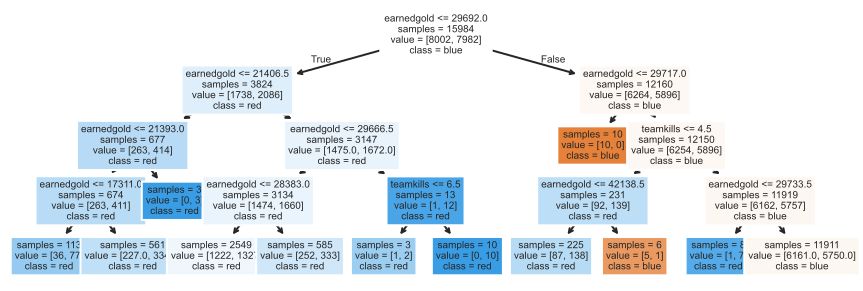

In [126]:
X_train, X_test, y_train, y_test = (
    train_test_split(teams[['teamkills', 'earnedgold']], teams['side'], random_state=1)
)

dtb = DecisionTreeClassifier(max_depth=4, criterion='entropy')
dtb.fit(X_train, y_train)

plt.figure(figsize=(15, 5))
plot_tree(dtb, feature_names=X_train.columns, class_names=['blue', 'red'], 
          filled=True, fontsize=10, impurity=False);

dtb.score(X_train, y_train), dtb.score(X_test, y_test)

### Base Model w/ Random Forest Classifier based on the in-game statistics can we predict wether the winning side of a game was blue or red

In [127]:
at_least_25['winner'] = at_least_25.apply(lambda row: row['side'] if row['result'] == 1 else ('Red' if row['side'] == 'Blue' else 'Blue'), axis=1)

In [128]:
X_raw = at_least_25[['teamkills', 'earnedgold', 'damagetochampions', 'xpat25', 'csat25', 'dragons', 'barons']]
y_raw = at_least_25['winner']

X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, random_state=1)

raw_model = RandomForestClassifier()

raw_model.fit(X_train, y_train)

RandomForestClassifier()

In [129]:
raw_model.score(X_train, y_train), raw_model.score(X_test, y_test)

(1.0, 0.5339622641509434)

### Base Model w/ Random Forest Classifier based on the difference in teamkills and earned gold can we predict wether the winning side of a game was blue or red

In [130]:

X_train, X_test, y_train, y_test = train_test_split(diffs_df[['teamkills', 'earnedgold']], diffs_df['winner'], random_state=1)
diffs_model_on_eg_tk = RandomForestClassifier()
diffs_model_on_eg_tk.fit(X_train, y_train)


RandomForestClassifier()

In [131]:
# This model is actually really good. Differences make a lot of difference lol. 
diffs_model_on_eg_tk.score(X_train, y_train), diffs_model_on_eg_tk.score(X_test, y_test)

(1.0, 0.9748427672955975)

## Step 7: Final Model

### Final Model w/ Decision Tree

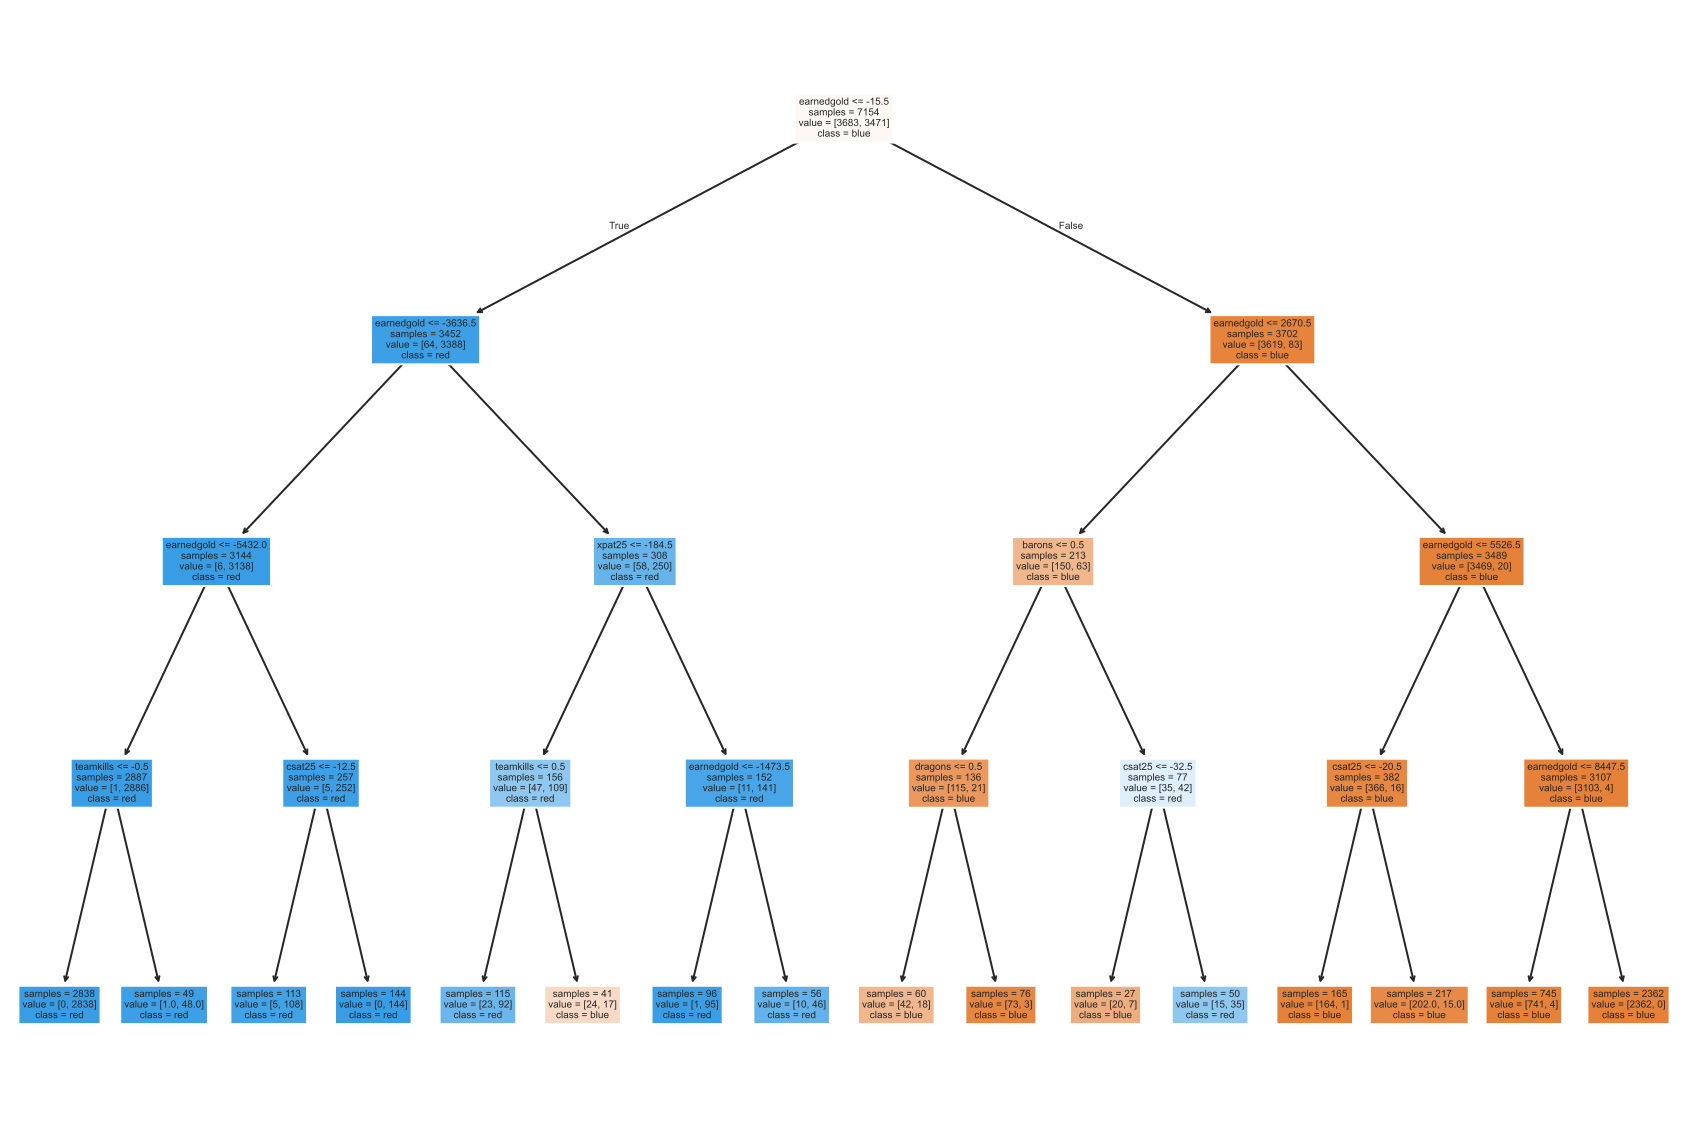

In [132]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = (
    train_test_split(diffs_df.drop(columns='winner'), diffs_df['winner'], random_state=1)
)

# Fit the decision tree model
dtf = DecisionTreeClassifier(max_depth=4, criterion='entropy')
dtf.fit(X_train, y_train)


# Plot the decision tree
plt.figure(figsize=(30, 20))
plot_tree(dtf, feature_names=X_train.columns, class_names=['blue', 'red'], 
          filled=True, fontsize=10, impurity=False);

In [133]:
# Calculate the accuracy of the model
dtf.score(X_train, y_train), dtf.score(X_test, y_test)

(0.9832261671792004, 0.9786163522012579)

### Final Model w/ Random Forest Classifier

In [134]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = (
    train_test_split(diffs_df.drop(columns=['winner']), diffs_df['winner'], random_state=1)
)
# Fit the random forest model
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

RandomForestClassifier()

In [135]:
# Calculate the accuracy of the model
clf.score(X_train, y_train) , clf.score(X_test, y_test)

(1.0, 0.9819706498951782)

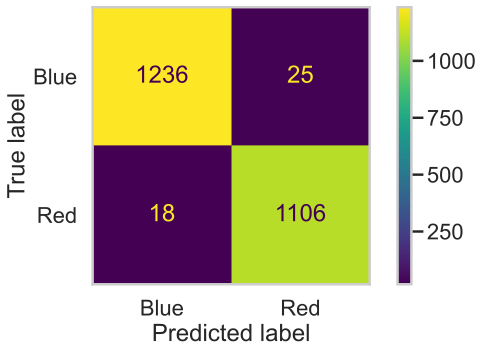

In [151]:
# Predict the test data
y_pred = clf.predict(X_test)
# Plot the confusion matrix
metrics.confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test);
plt.grid(False)

In [156]:
# Model Evaluation Scores
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Blue       0.99      0.98      0.98      1261
         Red       0.98      0.98      0.98      1124

    accuracy                           0.98      2385
   macro avg       0.98      0.98      0.98      2385
weighted avg       0.98      0.98      0.98      2385



In [159]:
metrics.f1_score(y_test, clf.predict(X_test), pos_label='Blue'), metrics.f1_score(y_test, clf.predict(X_test), pos_label='Red')

(np.float64(0.9829025844930418), np.float64(0.9809312638580931))

### Grid Search for Best Hyperparameters for DecisionTreeClassifier

In [ ]:
# Grid search for best hyperparameters
# Update the hyperparameters dictionary to things that actually matter.  
hyperparameters = {
    'max_depth': [2, 3, 4, 5, 7, 10, 13, 15, 18, None], 
    'min_samples_split': [2, 5, 10, 20, 50, 100, 200],
    'criterion': ['gini', 'entropy']
}

len(hyperparameters['max_depth']) * \
len(hyperparameters['min_samples_split']) * \
len(hyperparameters['criterion'])

searcher = GridSearchCV(DecisionTreeClassifier(), hyperparameters, cv=5)
searcher.fit(X_train, y_train)
searcher.best_params_

{'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 5}

In [ ]:
# Get the best model
searcher.cv_results_['mean_test_score']
pd.DataFrame(np.vstack([searcher.cv_results_[f'split{i}_test_score'] for i in range(5)]))

,0,1,2,3,...,136,137,138,139
0,0.98,0.98,0.98,0.98,...,0.98,0.98,0.98,0.98
1,0.98,0.98,0.98,0.98,...,0.98,0.98,0.98,0.98
2,0.98,0.98,0.98,0.98,...,0.97,0.97,0.97,0.98
3,0.98,0.98,0.98,0.98,...,0.98,0.97,0.97,0.97
4,0.98,0.98,0.98,0.98,...,0.97,0.97,0.98,0.98


In [ ]:
# Fit the best model
final_tree = DecisionTreeClassifier(**searcher.best_params_)
final_tree.fit(X_train, y_train)
final_tree.score(X_train, y_train), final_tree.score(X_test, y_test)

(0.984763768521107, 0.979454926624738)

### Grid Search for Best Hyperparameters for RandomForestClassifier

In [ ]:
# TODO

## Step 8: Fairness Analysis

In [ ]:
# TODO